# 题目三：机器学习策略开发与回测
- LSTM 价格预测模型
- 交易策略回测
- 风险评估

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sqlite3
import warnings
import os
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建输出目录
OUTPUT_DIR = '题目三_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print(f"题目三：LSTM 机器学习策略开发与回测")
print(f"输出目录: {OUTPUT_DIR}/")
print("=" * 60)

题目三：LSTM 机器学习策略开发与回测
输出目录: 题目三_output/


## 1. 数据加载

In [2]:
print("\n[1] 加载数据与特征融合...")

conn = sqlite3.connect('stock_data.db')

# --- 1.1 加载并对齐宏观与情绪特征 ---
external_features = None
try:
    # 加载宏观数据 (VIX -> market_volatility)
    # 注意：路径要指向正确生成的文件夹
    macro_df = pd.read_csv('题目三_stock_features_data/features_macro.csv')
    macro_df.rename(columns={'trade_date': 'date'}, inplace=True) # 统一列名以防万一
    macro_df['trade_date'] = pd.to_datetime(macro_df['date'] if 'date' in macro_df.columns else macro_df['trade_date'])
    
    if 'vix' in macro_df.columns:
        macro_df['market_volatility'] = macro_df['vix'] # 映射 VIX 为市场波动率特征
    
    # 加载情绪数据 (sentiment_score -> rsi_sentiment)
    senti_df = pd.read_csv('题目三_stock_features_data/features_sentiment.csv')
    senti_df['trade_date'] = pd.to_datetime(senti_df['trade_date'] if 'trade_date' in senti_df.columns else senti_df['date'])
    
    if 'sentiment_score' in senti_df.columns:
        senti_df['rsi_sentiment'] = senti_df['sentiment_score'] # 映射
    
    # 合并宏观与情绪
    external_features = pd.merge(macro_df[['trade_date', 'market_volatility']], 
                                 senti_df[['trade_date', 'rsi_sentiment']], 
                                 on='trade_date', how='outer')
    print(f"  ✓ 成功加载外部特征 (宏观+情绪): {len(external_features)} 条")
    print(f"    - Macro columns: {macro_df.columns.tolist()}")
    print(f"    - Sentiment columns: {senti_df.columns.tolist()}")
    
except Exception as e:
    print(f"  ! 外部特征加载异常 (将使用默认填充): {e}")

# --- 1.2 加载股票数据并补全特征 ---
stock_tables = {
    '600519.SH': 'feature_600519',
    '300750.SZ': 'feature_300750',
    '601318.SH': 'feature_601318',
    '000858.SZ': 'feature_000858',
    '600036.SH': 'feature_600036',
    '002594.SZ': 'feature_002594',
}

all_stock_data = {}

for code, table in stock_tables.items():
    # 从数据库读取基础数据
    try:
        df_stock = pd.read_sql(f'SELECT * FROM {table}', conn)
    except:
        # 如果找不到表，尝试直接用 Tushare 获取或跳过
        print(f"  x 无法从数据库找到 {table}，跳过")
        continue

    df_stock['trade_date'] = pd.to_datetime(df_stock['trade_date'])
    df_stock = df_stock.sort_values('trade_date').reset_index(drop=True)
    
    # [补全特征 1]: 内部量价特征 (Volume Ratio, Turnover)
    # volume_ratio: 量比 (此处简化为 当日量 / 5日均量)
    df_stock['vol_ma5'] = df_stock['vol'].rolling(5).mean()
    df_stock['volume_ratio'] = df_stock['vol'] / df_stock['vol_ma5']
    
    # turnover_rate: 如果数据库里没有，我们大概估算 (vol / 流通股本)，这里没有股本数据，
    # 暂时用 vol 的对数变化代替，或者如果原表有就用原表的
    if 'turnover_rate' not in df_stock.columns:
        # 简化替代：使用归一化的成交量作为代理
        df_stock['turnover_rate'] = np.log1p(df_stock['vol']) 

    # [补全特征 2]: 合并外部特征 (Market Volatility, Sentiment)
    if external_features is not None:
        df_stock = pd.merge(df_stock, external_features, on='trade_date', how='left')
    
    # 填充缺失值 (特别是外部特征合并后的空值)
    df_stock = df_stock.fillna(method='ffill').fillna(0)
    
    all_stock_data[code] = df_stock
    # print(f"  ✓ {code}: {len(df_stock)} 条 (特征补全: Volatility, Sentiment, VolRatio)")

print("所有数据加载完成。")
conn.close()


[1] 加载数据与特征融合...
  ✓ 成功加载外部特征 (宏观+情绪): 790 条
    - Macro columns: ['date', 'cn_us_spread', 'vix', 'trade_date', 'market_volatility']
    - Sentiment columns: ['trade_date', 'sentiment_score', 'baidu_index', 'rsi_sentiment']
所有数据加载完成。


## 2. LSTM 模型定义

In [3]:
print("\n[2] 定义 LSTM 模型...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  使用设备: {device}")

class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        return self.fc(last_output)


[2] 定义 LSTM 模型...
  使用设备: cuda


## 3. 数据准备与训练

In [4]:
print("\n[3] 训练 LSTM 模型...")

SEQ_LENGTH = 20
PRED_DAYS = 5        # 预测未来 5 日收益率
TRAIN_RATIO = 0.8
EPOCHS = 50
# 增加情绪指标特征
FEATURE_COLS = ['MACD_DIF', 'MACD_DEA', 'MACD_Hist', 'RSI_14', 
                'BOLL_MID', 'BOLL_UP', 'BOLL_DN', 'turnover_rate',
                'market_volatility', 'rsi_sentiment', 'volume_ratio']

def prepare_data(stock_df):
    data = stock_df.copy()
    
    # 核心：计算未来 5 日收益率作为预测目标
    # pct_change(5) 计算5天后的价格变化率
    # shift(-5) 将未来的数据对齐到当前行，实现"预测未来"
    data['target'] = data['close'].pct_change(PRED_DAYS).shift(-PRED_DAYS)
    
    available_cols = [c for c in FEATURE_COLS if c in data.columns]
    # 打印缺失特征警告
    missing_cols = set(FEATURE_COLS) - set(available_cols)
    if missing_cols:
        print(f"    警告: 缺失特征 {missing_cols}")
    
    if len(available_cols) < 3:
        return None
    
    data = data.dropna(subset=['target'] + available_cols)
    if len(data) < SEQ_LENGTH + 50:
        return None
    
    features = data[available_cols].values
    target = data['target'].values
    dates = data['trade_date'].values
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    X, y, d = [], [], []
    for i in range(len(features_scaled) - SEQ_LENGTH):
        X.append(features_scaled[i:i+SEQ_LENGTH])
        y.append(target[i + SEQ_LENGTH])
        d.append(dates[i + SEQ_LENGTH])
    
    X, y = np.array(X), np.array(y)
    split_idx = int(len(X) * TRAIN_RATIO)
    
    return {
        'X_train': X[:split_idx], 'y_train': y[:split_idx],
        'X_test': X[split_idx:], 'y_test': y[split_idx:],
        'test_dates': d[split_idx:], 'input_dim': len(available_cols)
    }

def train_model(X_train, y_train, input_dim):
    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    
    model = LSTMPredictor(input_dim=input_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = criterion(model(X_tensor), y_tensor)
        loss.backward()
        optimizer.step()
    
    return model, loss.item()

# 训练所有股票
all_results = {}
model_metrics = []

for code, stock_df in all_stock_data.items():
    print(f"\n  训练: {code}")
    
    data = prepare_data(stock_df)
    if data is None:
        print(f"    数据不足，跳过")
        continue
    
    model, final_loss = train_model(data['X_train'], data['y_train'], data['input_dim'])
    
    # 预测
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(data['X_test'], dtype=torch.float32).to(device)
        predictions = model(X_test_tensor).cpu().numpy().flatten()
    
    # 评估
    y_test = data['y_test']
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    ic = np.corrcoef(predictions, y_test)[0, 1]
    direction_acc = np.mean(np.sign(predictions) == np.sign(y_test))
    
    print(f"    Loss: {final_loss:.6f} | IC: {ic:.4f} | 方向准确率: {direction_acc:.2%}")
    
    all_results[code] = {
        'predictions': predictions,
        'actual': y_test,
        'test_dates': data['test_dates'],
        'stock_df': stock_df
    }
    
    model_metrics.append({
        '股票': code, 'MSE': mse, 'MAE': mae, 'IC': ic, '方向准确率': direction_acc
    })


[3] 训练 LSTM 模型...

  训练: 600519.SH
    Loss: 0.001898 | IC: 0.2634 | 方向准确率: 43.82%

  训练: 300750.SZ
    Loss: 0.005562 | IC: 0.0021 | 方向准确率: 56.18%

  训练: 601318.SH
    Loss: 0.002336 | IC: 0.0431 | 方向准确率: 57.60%

  训练: 000858.SZ
    Loss: 0.003171 | IC: 0.0676 | 方向准确率: 47.00%

  训练: 600036.SH
    Loss: 0.002170 | IC: 0.0639 | 方向准确率: 49.47%

  训练: 002594.SZ
    Loss: 0.004032 | IC: 0.0528 | 方向准确率: 51.94%


## 4. 模型评估汇总

In [5]:
print("\n" + "=" * 60)
print("[4] 模型评估汇总")
print("=" * 60)
metrics_df = pd.DataFrame(model_metrics)
print(metrics_df.to_string(index=False))


[4] 模型评估汇总
       股票      MSE      MAE       IC    方向准确率
600519.SH 0.000731 0.022332 0.263401 0.438163
300750.SZ 0.002362 0.037391 0.002112 0.561837
601318.SH 0.000903 0.022963 0.043138 0.575972
000858.SZ 0.000782 0.022496 0.067575 0.469965
600036.SH 0.000639 0.019720 0.063940 0.494700
002594.SZ 0.010799 0.050915 0.052837 0.519435


## 5. 交易策略回测

In [6]:
print("\n" + "=" * 60)
print("[5] 交易策略回测")
print("=" * 60)

INITIAL_CAPITAL = 1000000
BUY_THRESHOLD = 0.01
HOLD_DAYS = 5

def backtest(stock_df, predictions, test_dates):
    stock_df = stock_df.copy().sort_values('trade_date').reset_index(drop=True)
    date_to_idx = {d: i for i, d in enumerate(stock_df['trade_date'])}
    
    trades = []
    cash = INITIAL_CAPITAL
    position = 0
    entry_price = entry_date = None
    hold_count = 0
    equity_history = []
    
    for pred, date in zip(predictions, test_dates):
        date = pd.to_datetime(date)
        if date not in date_to_idx:
            continue
        
        idx = date_to_idx[date]
        if idx >= len(stock_df) - 1:
            continue
        
        current_price = stock_df.iloc[idx]['close']
        next_open = stock_df.iloc[idx + 1]['open']
        
        # 持仓检查
        if position > 0:
            hold_count += 1
            if hold_count >= HOLD_DAYS:
                profit_pct = current_price / entry_price - 1
                trades.append({
                    '买入日期': entry_date, '卖出日期': date,
                    '买入价': entry_price, '卖出价': current_price,
                    '收益率': profit_pct
                })
                cash += current_price * position
                position = 0
                hold_count = 0
        
        # 买入信号
        if position == 0 and pred > BUY_THRESHOLD:
            position = int(cash * 0.95 / next_open / 100) * 100
            if position > 0:
                cash -= next_open * position
                entry_price = next_open
                entry_date = date
                hold_count = 0
        
        equity_history.append(cash + position * current_price)
    
    return trades, equity_history

backtest_results = {}
all_trades = []

for code, result in all_results.items():
    trades, equity = backtest(result['stock_df'], result['predictions'], result['test_dates'])
    backtest_results[code] = {'trades': trades, 'equity': equity}
    
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        win_rate = (trades_df['收益率'] > 0).mean()
        avg_return = trades_df['收益率'].mean()
        
        print(f"\n{code}:")
        print(f"  交易次数: {len(trades)}")
        print(f"  胜率: {win_rate:.2%}")
        print(f"  平均收益: {avg_return:.2%}")
        
        if len(equity) > 0:
            total_return = (equity[-1] / INITIAL_CAPITAL - 1)
            print(f"  总收益率: {total_return:.2%}")
        
        for t in trades:
            t['股票'] = code
        all_trades.extend(trades)
    else:
        print(f"\n{code}: 无交易信号")


[5] 交易策略回测

600519.SH:
  交易次数: 48
  胜率: 47.92%
  平均收益: 0.19%
  总收益率: 6.16%

300750.SZ:
  交易次数: 38
  胜率: 50.00%
  平均收益: 1.00%
  总收益率: 35.27%

601318.SH:
  交易次数: 24
  胜率: 50.00%
  平均收益: 0.33%
  总收益率: 6.79%

000858.SZ:
  交易次数: 18
  胜率: 50.00%
  平均收益: 0.33%
  总收益率: 5.24%

600036.SH:
  交易次数: 2
  胜率: 100.00%
  平均收益: 1.75%
  总收益率: 3.32%

002594.SZ:
  交易次数: 18
  胜率: 38.89%
  平均收益: -0.02%
  总收益率: -1.21%


## 6. 交易清单

In [7]:
print("\n" + "=" * 60)
print("[6] 交易清单")
print("=" * 60)

if len(all_trades) > 0:
    trades_df = pd.DataFrame(all_trades)
    trades_df['收益率'] = trades_df['收益率'].apply(lambda x: f"{x:.2%}")
    print(trades_df[['股票', '买入日期', '卖出日期', '买入价', '卖出价', '收益率']].to_string(index=False))
    
    trades_df.to_csv(f'{OUTPUT_DIR}/trade_list.csv', index=False, encoding='utf-8-sig')
    print(f"\n已保存: {OUTPUT_DIR}/trade_list.csv")
else:
    print("无交易记录")


[6] 交易清单
       股票       买入日期       卖出日期     买入价     卖出价     收益率
600519.SH 2024-10-30 2024-11-06 1532.15 1571.00   2.54%
600519.SH 2024-11-06 2024-11-13 1562.46 1578.50   1.03%
600519.SH 2024-11-13 2024-11-20 1570.00 1544.81  -1.60%
600519.SH 2024-11-20 2024-11-27 1543.87 1519.05  -1.61%
600519.SH 2024-11-27 2024-12-04 1522.00 1520.00  -0.13%
600519.SH 2024-12-04 2024-12-11 1510.86 1535.60   1.64%
600519.SH 2024-12-12 2024-12-19 1550.01 1551.01   0.06%
600519.SH 2024-12-19 2024-12-26 1531.13 1527.79  -0.22%
600519.SH 2024-12-26 2025-01-03 1528.90 1475.00  -3.53%
600519.SH 2025-01-03 2025-01-10 1453.00 1436.00  -1.17%
600519.SH 2025-01-10 2025-01-17 1425.00 1454.75   2.09%
600519.SH 2025-02-05 2025-02-12 1400.01 1443.00   3.07%
600519.SH 2025-02-12 2025-02-19 1443.02 1491.00   3.32%
600519.SH 2025-02-19 2025-02-26 1483.00 1460.01  -1.55%
600519.SH 2025-02-26 2025-03-05 1460.02 1466.37   0.43%
600519.SH 2025-03-05 2025-03-12 1474.00 1542.58   4.65%
600519.SH 2025-03-12 2025-03-19 1544.0

## 7. 风险评估

In [8]:
print("\n" + "=" * 60)
print("[7] 风险评估指标")
print("=" * 60)

risk_metrics = []
for code, result in backtest_results.items():
    equity = result['equity']
    if len(equity) < 2:
        continue
    
    equity = np.array(equity)
    returns = np.diff(equity) / equity[:-1]
    
    total_return = equity[-1] / equity[0] - 1
    max_dd = np.min(equity / np.maximum.accumulate(equity) - 1)
    sharpe = (np.mean(returns) * 252 - 0.03) / (np.std(returns) * np.sqrt(252)) if np.std(returns) > 0 else 0
    
    trades = result['trades']
    win_rate = sum(1 for t in trades if t['收益率'] > 0) / len(trades) if trades else 0
    
    risk_metrics.append({
        '股票': code,
        '总收益率': f"{total_return:.2%}",
        '最大回撤': f"{max_dd:.2%}",
        '夏普比率': f"{sharpe:.2f}",
        '交易次数': len(trades),
        '胜率': f"{win_rate:.2%}"
    })

risk_df = pd.DataFrame(risk_metrics)
print(risk_df.to_string(index=False))
risk_df.to_csv(f'{OUTPUT_DIR}/risk_metrics.csv', index=False, encoding='utf-8-sig')
print(f"\n已保存: {OUTPUT_DIR}/risk_metrics.csv")

print("\n" + "=" * 60)
print("运行完成!")
print("=" * 60)


[7] 风险评估指标
       股票   总收益率    最大回撤  夏普比率  交易次数      胜率
600519.SH  6.17%  -9.33%  0.23    48  47.92%
300750.SZ 34.74% -22.76%  0.93    38  50.00%
601318.SH  6.79% -14.64%  0.26    24  50.00%
000858.SZ  4.04% -12.44%  0.11    18  50.00%
600036.SH  3.32%  -1.64% -0.01     2 100.00%
002594.SZ -1.21% -16.71% -0.16    18  38.89%

已保存: 题目三_output/risk_metrics.csv

运行完成!


## 8. 结果可视化


[8] 结果可视化


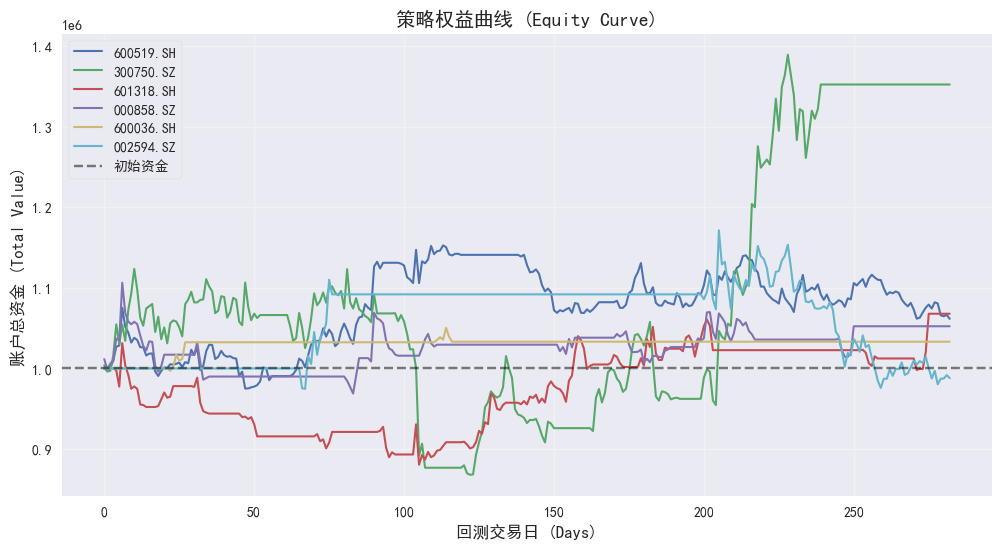

已保存: 题目三_output/equity_curve.png


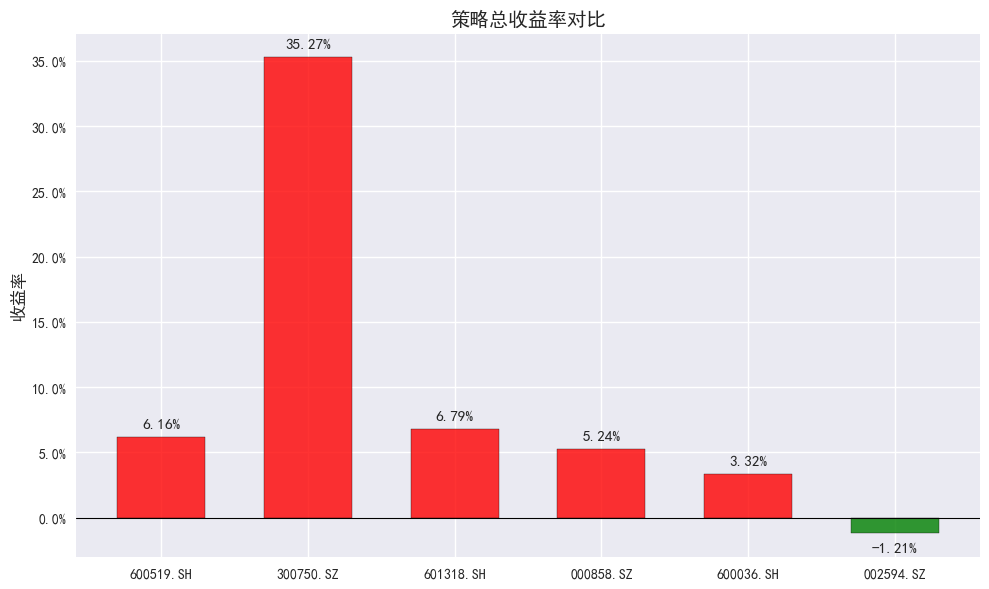

已保存: 题目三_output/strategy_comparison.png

绘制持仓热力图...


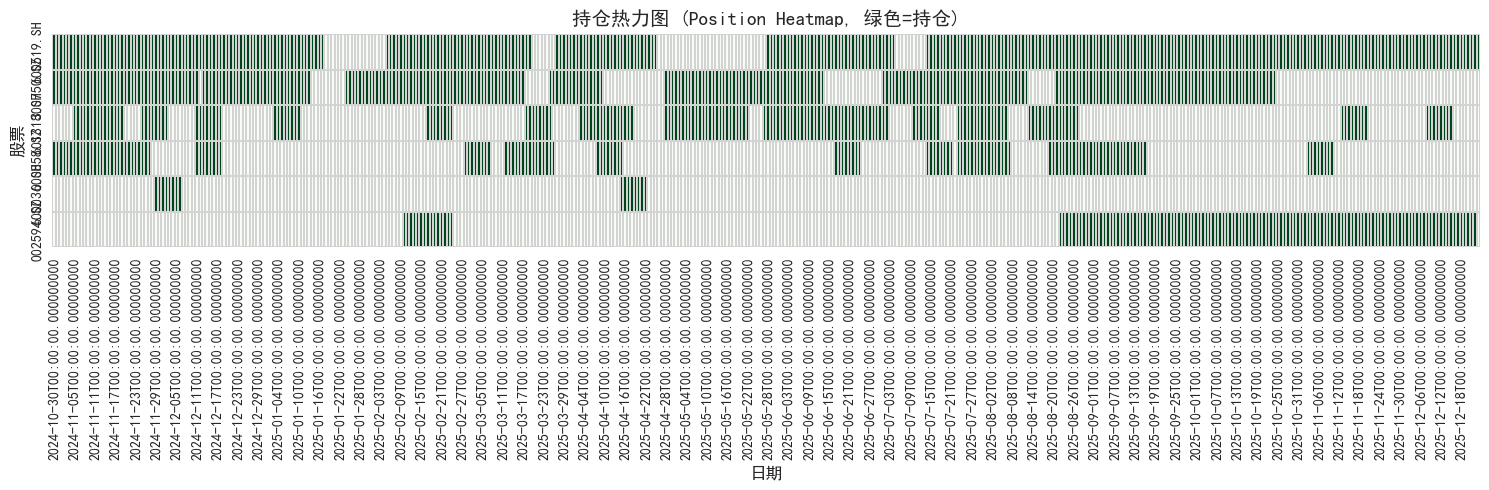

已保存: 题目三_output/position_heatmap.png


In [9]:
print("\n" + "=" * 60)
print("[8] 结果可视化")
print("=" * 60)

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 设置绘图风格
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 绘制权益曲线
plt.figure(figsize=(12, 6))
for code, result in backtest_results.items():
    equity = result['equity']
    if len(equity) > 0:
        values = np.array(equity)
        plt.plot(values, label=f'{code}', linewidth=1.5)

plt.axhline(y=INITIAL_CAPITAL, color='black', linestyle='--', alpha=0.5, label='初始资金')
plt.title('策略权益曲线 (Equity Curve)', fontsize=14)
plt.xlabel('回测交易日 (Days)', fontsize=12)
plt.ylabel('账户总资金 (Total Value)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: {OUTPUT_DIR}/equity_curve.png")

# 2. 收益率对比柱状图
plt.figure(figsize=(10, 6))
returns_data = []
for code, result in backtest_results.items():
    equity = result['equity']
    if len(equity) > 0:
        total_ret = equity[-1] / INITIAL_CAPITAL - 1
        returns_data.append({'股票': code, '总收益率': total_ret})

if returns_data:
    df_plot = pd.DataFrame(returns_data)
    colors = ['red' if x > 0 else 'green' for x in df_plot['总收益率']]
    bars = plt.bar(df_plot['股票'], df_plot['总收益率'], color=colors, alpha=0.8, edgecolor='black', width=0.6)
    plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
    plt.title('策略总收益率对比', fontsize=14)
    plt.ylabel('收益率', fontsize=12)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for bar in bars:
        height = bar.get_height()
        xy_pos = (bar.get_x() + bar.get_width() / 2, height)
        xy_text = (0, 5) if height > 0 else (0, -15)
        plt.annotate(f'{height:.2%}', xy=xy_pos, xytext=xy_text,
                     textcoords="offset points", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/strategy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"已保存: {OUTPUT_DIR}/strategy_comparison.png")

# 3. 持仓热力图 (Position Heatmap)
print("\n绘制持仓热力图...")
# 收集所有日期
all_dates = set()
for code, result in backtest_results.items():
    for trade in result['trades']:
        all_dates.add(pd.to_datetime(trade['买入日期']))
        all_dates.add(pd.to_datetime(trade['卖出日期']))
    # 也加入equity中的日期以确保范围完整
    # (简化起见，这里主要关注有交易的日期范围)

if len(all_dates) > 0:
    min_date = min(all_dates)
    max_date = max(all_dates)
    date_range = pd.date_range(start=min_date, end=max_date, freq='D')
    
    # 创建持仓矩阵 (Stock x Date)
    position_matrix = pd.DataFrame(0, index=backtest_results.keys(), columns=date_range)
    
    for code, result in backtest_results.items():
        for trade in result['trades']:
            buy_date = pd.to_datetime(trade['买入日期'])
            sell_date = pd.to_datetime(trade['卖出日期'])
            position_matrix.loc[code, buy_date:sell_date] = 1 # 1表示持仓
            
    # 绘制热力图 (仅显示有交易的时间段)
    # 为了美观，可以按周降采样或者直接画
    plt.figure(figsize=(15, 5))
    sns.heatmap(position_matrix, cmap='Greens', cbar=False, linewidths=0.05, linecolor='lightgray')
    plt.title('持仓热力图 (Position Heatmap, 绿色=持仓)', fontsize=14)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('股票', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/position_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"已保存: {OUTPUT_DIR}/position_heatmap.png")
else:
    print("无交易记录，无法绘制热力图")